# 01 — Exploratory Data Analysis (EDA)

Notebook ini memvisualisasikan dataset Cassava Leaf Disease:
- Distribusi kelas (histogram)
- Contoh citra per kelas
- Statistik dataset (ukuran, resolusi, dsb)
- Distribusi per split (train/val/test)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/ahmdzaidan/cassava-lora.git
%cd cassava-lora

Mounted at /content/drive
Cloning into 'cassava-lora'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 135 (delta 36), reused 123 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 3.93 MiB | 27.93 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/cassava-lora


In [2]:
# Install Requirements
!pip install -q -r /content/cassava-lora/requirements.txt
!python -c "import torch, transformers, peft; print('OK')"
!python -c "import torch; print('GPU:', torch.cuda.is_available())"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-clien

In [4]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random

from src.utils.config import load_config

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load config
config = load_config('./configs/data.yaml')
print('Config loaded successfully.')

Config loaded successfully.


## 1. Distribusi Kelas

In [5]:
# Load class distribution
dist_path = './reports/tables/class_distribution.csv'
if Path(dist_path).exists():
    dist_df = pd.read_csv(dist_path)
    display(dist_df)
else:
    print('Run preprocessing first: python -m src.data.preprocessing --config configs/data.yaml')

# Load splits
splits_dir = Path('./data/splits')
splits = {}
for split_name in ['train', 'val', 'test']:
    csv_path = splits_dir / f'{split_name}.csv'
    if csv_path.exists():
        splits[split_name] = pd.read_csv(csv_path)
        print(f'{split_name}: {len(splits[split_name])} samples')

,split,class_name,count,percentage
0,train,cbb,326,8.23
1,train,cbsd,1010,25.51
2,train,cgm,541,13.67
3,train,cmd,1861,47.01
4,train,healthy,221,5.58
5,val,cbb,70,8.25
6,val,cbsd,216,25.47
7,val,cgm,116,13.68
8,val,cmd,398,46.93
9,val,healthy,48,5.66


train: 3959 samples
val: 848 samples
test: 849 samples


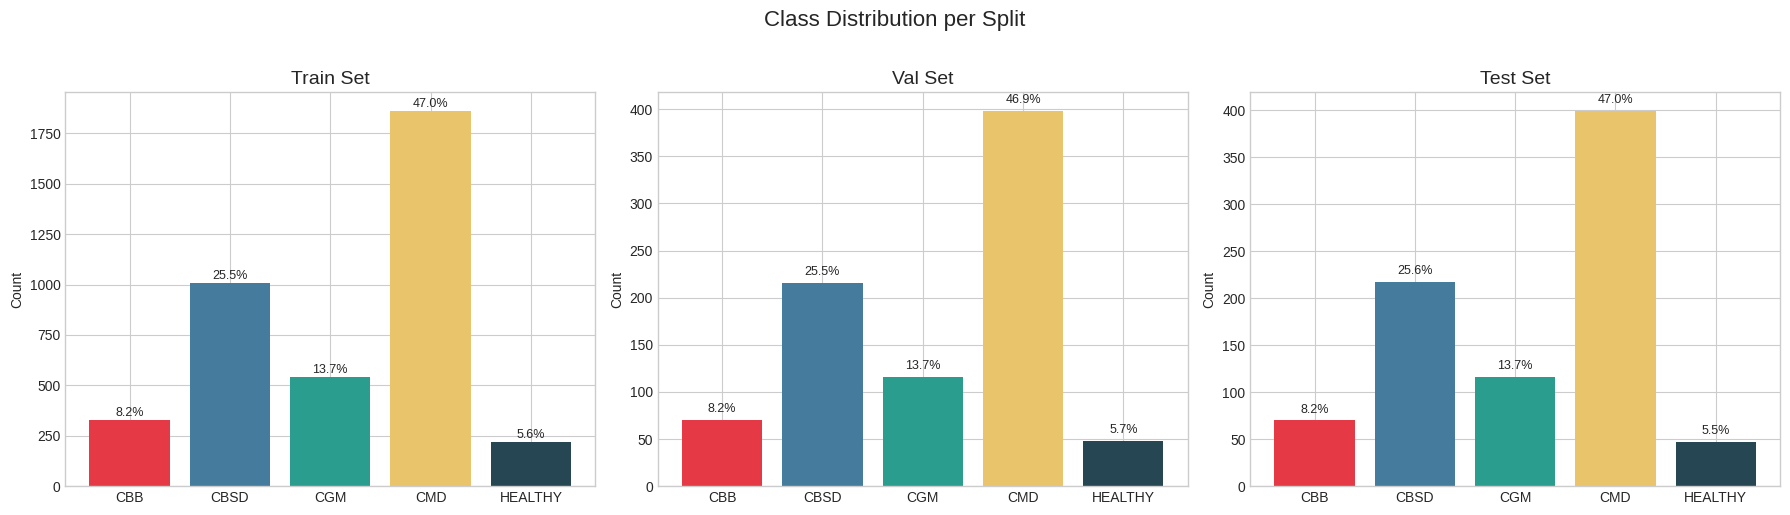

In [6]:
# Plot distribusi kelas per split
if dist_df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    class_colors = {
        'cbb': '#E63946', 'cbsd': '#457B9D', 'cgm': '#2A9D8F',
        'cmd': '#E9C46A', 'healthy': '#264653'
    }

    for ax, split_name in zip(axes, ['train', 'val', 'test']):
        split_data = dist_df[dist_df['split'] == split_name]
        colors = [class_colors[c] for c in split_data['class_name']]

        bars = ax.bar(split_data['class_name'].str.upper(), split_data['count'], color=colors)
        ax.set_title(f'{split_name.capitalize()} Set', fontsize=14)
        ax.set_ylabel('Count')

        for bar, pct in zip(bars, split_data['percentage']):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    fig.suptitle('Class Distribution per Split', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('./reports/figures/fig_EDA_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

## 2. Contoh Citra per Kelas

In [7]:
# Tampilkan contoh gambar per kelas
if 'train' in splits:
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))

    class_names = ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
    class_labels_pretty = {
        'cbb': 'Bacterial Blight', 'cbsd': 'Brown Streak',
        'cgm': 'Green Mottle', 'cmd': 'Mosaic Disease', 'healthy': 'Healthy'
    }

    train_df = splits['train']

    for row_idx, cls_name in enumerate(class_names):
        cls_df = train_df[train_df['class_name'] == cls_name]
        samples = cls_df.sample(min(5, len(cls_df)), random_state=42)

        for col_idx, (_, sample) in enumerate(samples.iterrows()):
            try:
                img = Image.open(sample['image_path']).resize((224, 224))
                axes[row_idx, col_idx].imshow(img)
            except:
                axes[row_idx, col_idx].text(0.5, 0.5, 'Error', ha='center')

            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(
                    class_labels_pretty[cls_name], fontsize=12, rotation=0,
                    labelpad=80, va='center'
                )

    fig.suptitle('Sample Images per Disease Class', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('./reports/figures/fig_EDA_sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 3. Statistik Gambar

Resolution (W x H):
  Width:  min=500, max=889, mean=611
  Height: min=500, max=1062, mean=577
  File size: min=38.3KB, max=348.8KB, mean=141.0KB


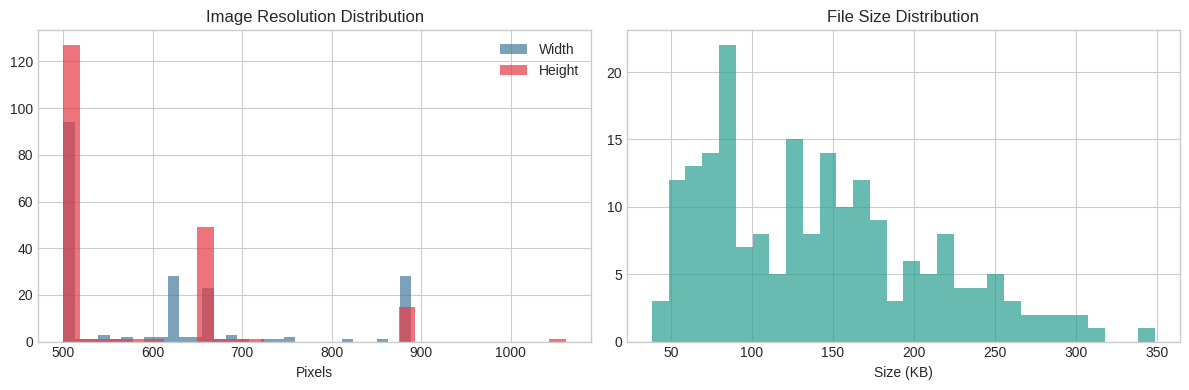

In [8]:
# Analisis resolusi dan ukuran file
if 'train' in splits:
    sample = splits['train'].sample(min(200, len(splits['train'])), random_state=42)
    widths, heights, sizes = [], [], []

    for _, row in sample.iterrows():
        try:
            p = Path(row['image_path'])
            img = Image.open(p)
            widths.append(img.size[0])
            heights.append(img.size[1])
            sizes.append(p.stat().st_size / 1024)  # KB
        except:
            pass

    print(f'Resolution (W x H):')
    print(f'  Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
    print(f'  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')
    print(f'  File size: min={min(sizes):.1f}KB, max={max(sizes):.1f}KB, mean={np.mean(sizes):.1f}KB')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=30, alpha=0.7, color='#457B9D', label='Width')
    axes[0].hist(heights, bins=30, alpha=0.7, color='#E63946', label='Height')
    axes[0].set_title('Image Resolution Distribution')
    axes[0].set_xlabel('Pixels')
    axes[0].legend()

    axes[1].hist(sizes, bins=30, alpha=0.7, color='#2A9D8F')
    axes[1].set_title('File Size Distribution')
    axes[1].set_xlabel('Size (KB)')

    plt.tight_layout()
    plt.show()

## 4. Class Imbalance Analysis

In [11]:
# Load class weights
weights_path = './reports/tables/class_weights.csv'
if Path(weights_path).exists():
    weights_df = pd.read_csv(weights_path)
    print('Class Weights (for weighted sampling/loss):')
    display(weights_df)

    # Imbalance ratio
    if 'train' in splits:
        counts = splits['train']['class_name'].value_counts()
        ratio = counts.max() / counts.min()
        print(f'\nImbalance ratio (max/min): {ratio:.2f}x')
        print(f'Dominant class: {counts.idxmax()} ({counts.max()} samples)')
        print(f'Minority class: {counts.idxmin()} ({counts.min()} samples)')

Class Weights (for weighted sampling/loss):


,class_name,label,weight
0,cbb,0,2.428834
1,cbsd,1,0.783960
2,cgm,2,1.463586
3,cmd,3,0.425470
4,healthy,4,3.582805



Imbalance ratio (max/min): 8.42x
Dominant class: cmd (1861 samples)
Minority class: healthy (221 samples)
